In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from apyori import apriori
from collections import Counter


In [2]:
df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7501, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
transactions = []
for i in range(0, df.shape[0]): 
    transaction = [str(df.values[i, j]) for j in range(0, df.shape[1]) if pd.notna(df.values[i, j])]
    transactions.append(transaction)

print(f"Total transactions: {len(transactions)}")
print(f"Example transaction: {transactions[0]}")

Total transactions: 7501
Example transaction: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']


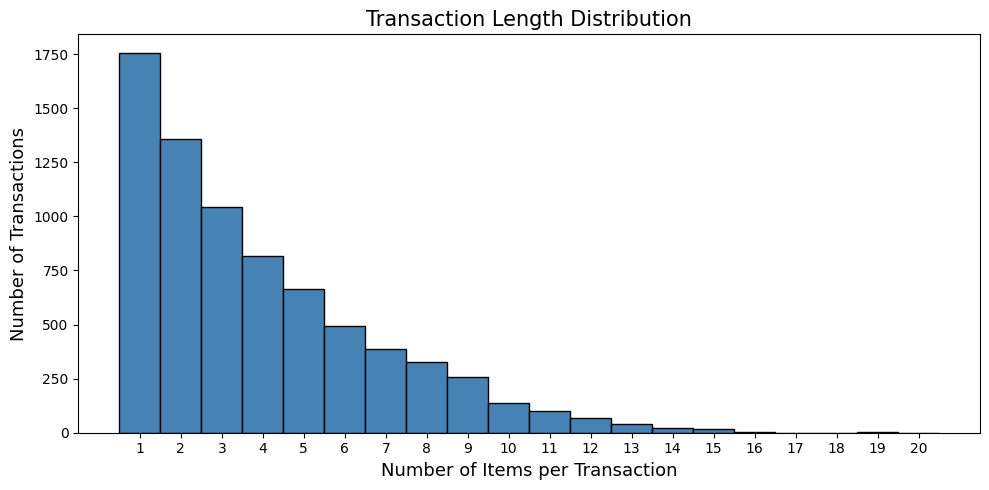

Min items: 1
Max items: 20
Average items per transaction: 3.91


In [4]:
lengths = [len(t) for t in transactions]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(lengths, bins=range(1, max(lengths)+2), color='steelblue', edgecolor='black', align='left')
ax.set_xlabel('Number of Items per Transaction', fontsize=13)
ax.set_ylabel('Number of Transactions', fontsize=13)
ax.set_title('Transaction Length Distribution', fontsize=15)
plt.xticks(range(1, max(lengths)+1))
plt.tight_layout()
plt.show()

print(f"Min items: {min(lengths)}")
print(f"Max items: {max(lengths)}")
print(f"Average items per transaction: {np.mean(lengths):.2f}")

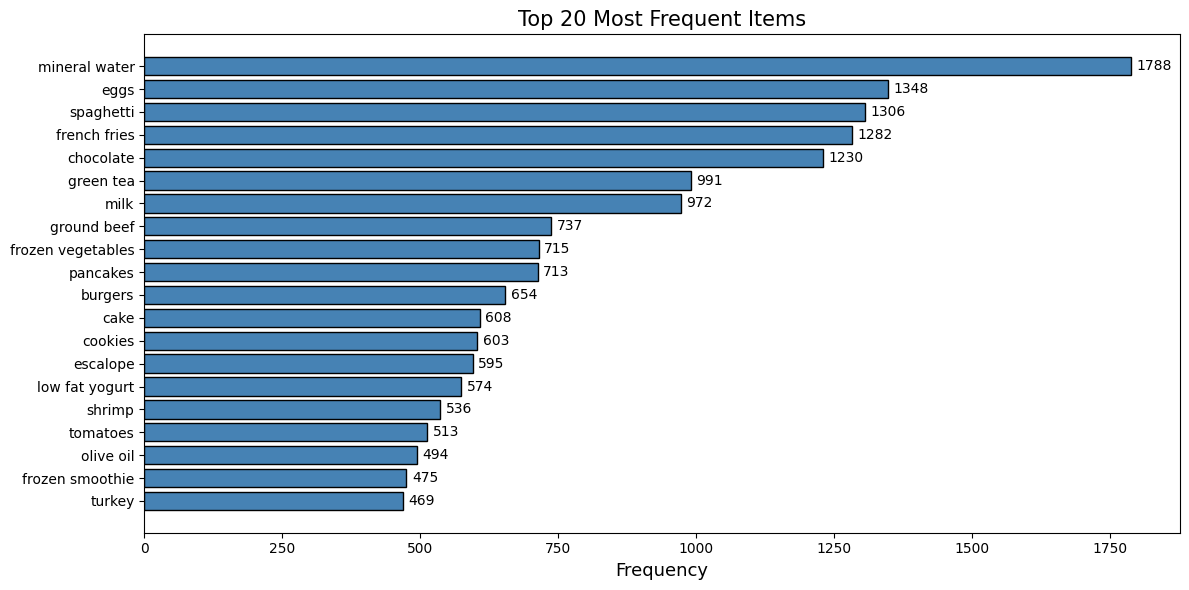

In [5]:
all_items = [item for transaction in transactions for item in transaction]
item_counts = Counter(all_items)
top20 = item_counts.most_common(20)
items_names, items_freq = zip(*top20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(items_names[::-1], items_freq[::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Frequency', fontsize=13)
ax.set_title('Top 20 Most Frequent Items', fontsize=15)

# Add frequency labels on bars
for bar, freq in zip(bars, items_freq[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(freq), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# min_support    = item appears in at least ~4 transactions per day (7 days) out of 7501
#                  => 4*7 / 7501 ≈ 0.0037, rounded to 0.003
# min_confidence = rule is correct at least 20% of the time
# min_lift       = only keep rules where lift > 1 (positive association)
# min_length     = at least 2 items (antecedent + consequent)

rules = list(apriori(
    transactions,
    min_support=0.003,
    min_confidence=0.2,
    min_lift=1
))

print(f"Total rules generated: {len(rules)}")

Total rules generated: 812


In [7]:
def parse_rules(results, min_rule_length=3):
    """
    Parse apyori results into a DataFrame.

    min_rule_length: minimum total number of items in a rule
                     (antecedent + consequent combined).
                     e.g. min_rule_length=2 means at least {A} -> {B}
                          min_rule_length=3 means at least {A,B} -> {C} or {A} -> {B,C}
    """
    rows = []
    for result in results:
        support = result.support
        for rule in result.ordered_statistics:
            antecedent = list(rule.items_base)
            consequent = list(rule.items_add)

            # Skip single-item entries (no antecedent)
            if len(antecedent) == 0:
                continue

            # Manually enforce minimum rule length
            total_length = len(antecedent) + len(consequent)
            if total_length < min_rule_length:
                continue

            confidence = rule.confidence
            lift = rule.lift
            rows.append({
                'Antecedent':       ', '.join(antecedent),
                'Consequent':       ', '.join(consequent),
                'Antecedent Length': len(antecedent),
                'Consequent Length': len(consequent),
                'Rule Length':       total_length,
                'Support':           round(support, 4),
                'Confidence':        round(confidence, 4),
                'Lift':              round(lift, 4)
            })

    return pd.DataFrame(rows)

rules_df = parse_rules(rules, min_rule_length=3)
rules_df = rules_df.sort_values('Lift', ascending=False).reset_index(drop=True)

print(f"Total association rules after filtering: {len(rules_df)}")
rules_df.head(10)

Total association rules after filtering: 1072


,Antecedent,Consequent,Antecedent Length,Consequent Length,Rule Length,Support,Confidence,Lift
0,"frozen vegetables, soup","mineral water, milk",2,2,4,0.0031,0.3833,7.9872
1,"frozen vegetables, olive oil","mineral water, milk",2,2,4,0.0033,0.2941,6.1283
2,"mineral water, whole wheat pasta",olive oil,2,1,3,0.0039,0.4028,6.1159
3,"soup, milk","frozen vegetables, mineral water",2,2,4,0.0031,0.2018,5.6469
4,tomato sauce,"spaghetti, ground beef",1,2,3,0.0031,0.2170,5.5360
5,"frozen vegetables, mineral water, milk",soup,3,1,4,0.0031,0.2771,5.4844
6,"spaghetti, tomato sauce",ground beef,2,1,3,0.0031,0.4894,4.9806
7,"french fries, herb & pepper",ground beef,2,1,3,0.0032,0.4615,4.6974
8,"cereals, spaghetti",ground beef,2,1,3,0.0031,0.4600,4.6818
9,"frozen vegetables, soup, mineral water",milk,3,1,4,0.0031,0.6053,4.6709


In [8]:
print("=== Support ===")
print(rules_df['Support'].describe().round(4))
print("\n=== Confidence ===")
print(rules_df['Confidence'].describe().round(4))
print("\n=== Lift ===")
print(rules_df['Lift'].describe().round(4))

=== Support ===
count    1072.0000
mean        0.0050
std         0.0023
min         0.0031
25%         0.0035
50%         0.0041
75%         0.0057
max         0.0171
Name: Support, dtype: float64

=== Confidence ===
count    1072.0000
mean        0.3304
std         0.0994
min         0.2000
25%         0.2500
50%         0.3049
75%         0.3978
max         0.7667
Name: Confidence, dtype: float64

=== Lift ===
count    1072.0000
mean        2.1538
std         0.7409
min         1.0392
25%         1.6482
50%         1.9969
75%         2.4721
max         7.9872
Name: Lift, dtype: float64


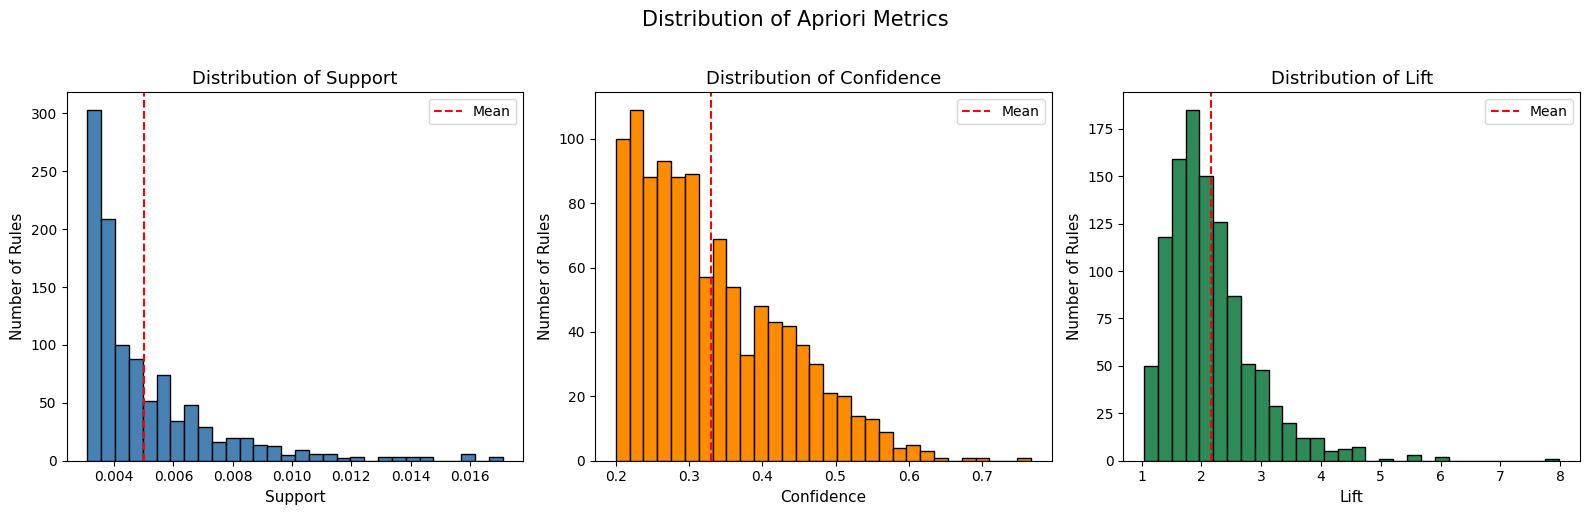

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color in zip(axes,
                              ['Support', 'Confidence', 'Lift'],
                              ['steelblue', 'darkorange', 'seagreen']):
    ax.hist(rules_df[metric], bins=30, color=color, edgecolor='black')
    ax.set_title(f'Distribution of {metric}', fontsize=13)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel('Number of Rules', fontsize=11)
    ax.axvline(rules_df[metric].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax.legend()

plt.suptitle('Distribution of Apriori Metrics', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

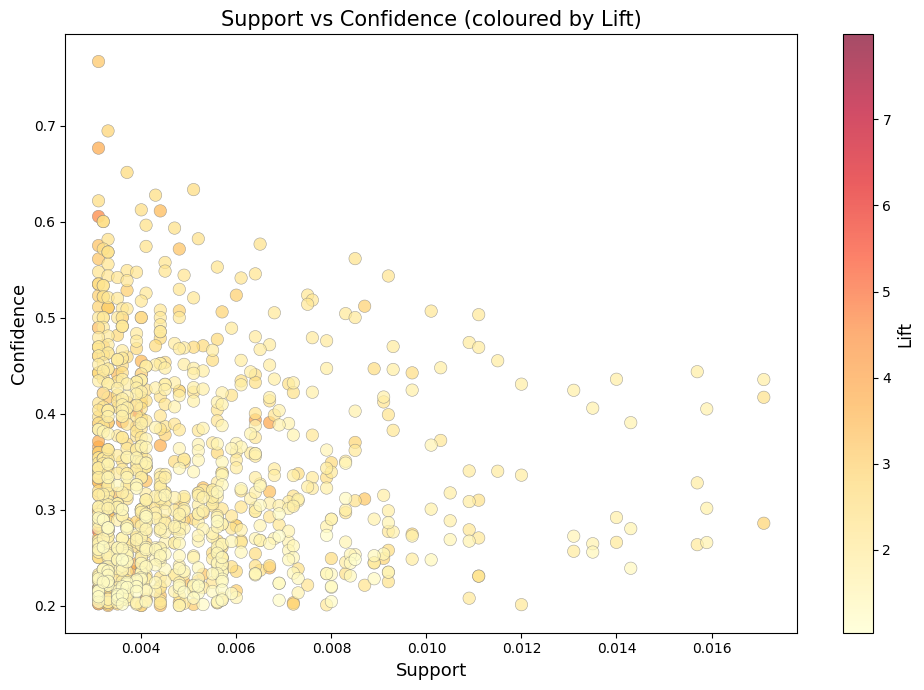

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    rules_df['Support'],
    rules_df['Confidence'],
    c=rules_df['Lift'],
    cmap='YlOrRd',
    s=80,
    alpha=0.7,
    edgecolors='grey',
    linewidths=0.4
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift', fontsize=12)
ax.set_xlabel('Support', fontsize=13)
ax.set_ylabel('Confidence', fontsize=13)
ax.set_title('Support vs Confidence (coloured by Lift)', fontsize=15)
plt.tight_layout()
plt.show()

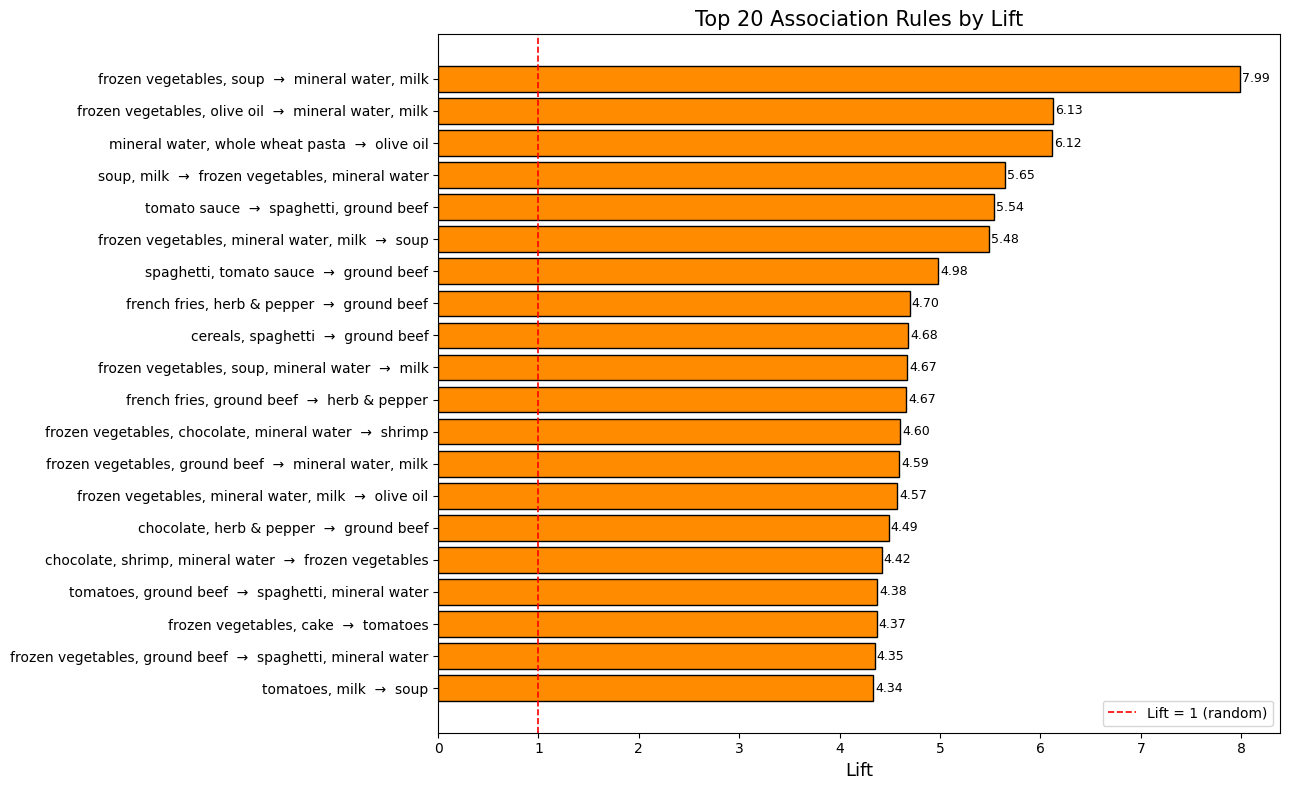

In [11]:
top20_rules = rules_df.head(20).copy()
top20_rules['Rule'] = top20_rules['Antecedent'] + '  →  ' + top20_rules['Consequent']

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(top20_rules['Rule'][::-1], top20_rules['Lift'][::-1],
               color='darkorange', edgecolor='black')

for bar, val in zip(bars, top20_rules['Lift'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Lift', fontsize=13)
ax.set_title('Top 20 Association Rules by Lift', fontsize=15)
ax.axvline(1, color='red', linestyle='--', linewidth=1.2, label='Lift = 1 (random)')
ax.legend()
plt.tight_layout()
plt.show()

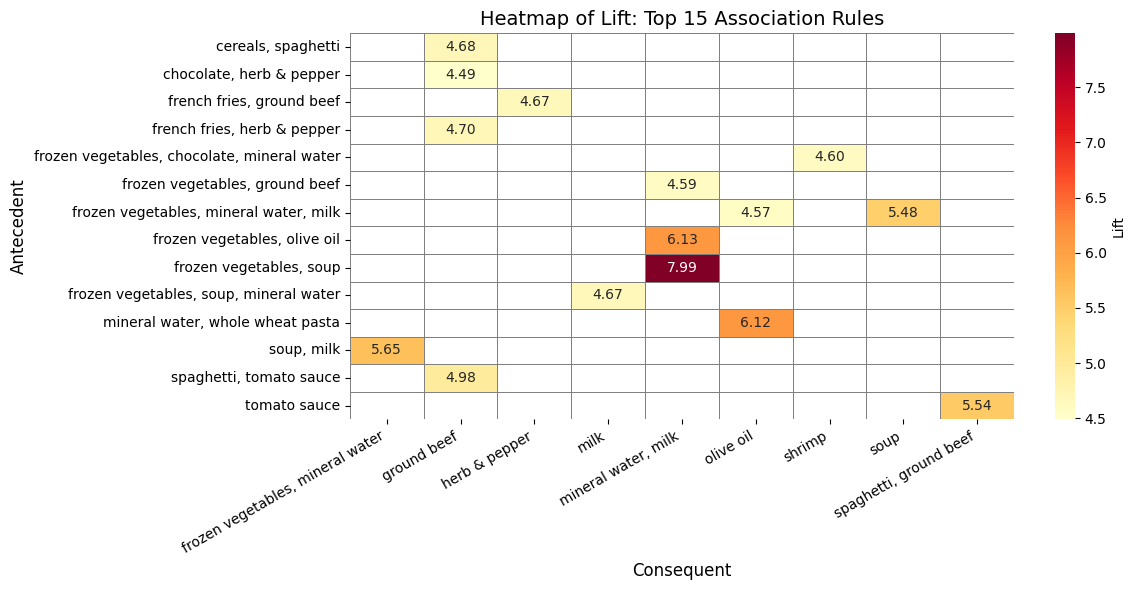

In [12]:
# Get top 15 rules for the heatmap
top_heat = rules_df.head(15)[['Antecedent', 'Consequent', 'Lift']].copy()

# Pivot into a matrix
pivot = top_heat.pivot_table(index='Antecedent', columns='Consequent', values='Lift', aggfunc='max')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='grey', ax=ax,
            cbar_kws={'label': 'Lift'})
ax.set_title('Heatmap of Lift: Top 15 Association Rules', fontsize=14)
ax.set_xlabel('Consequent', fontsize=12)
ax.set_ylabel('Antecedent', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

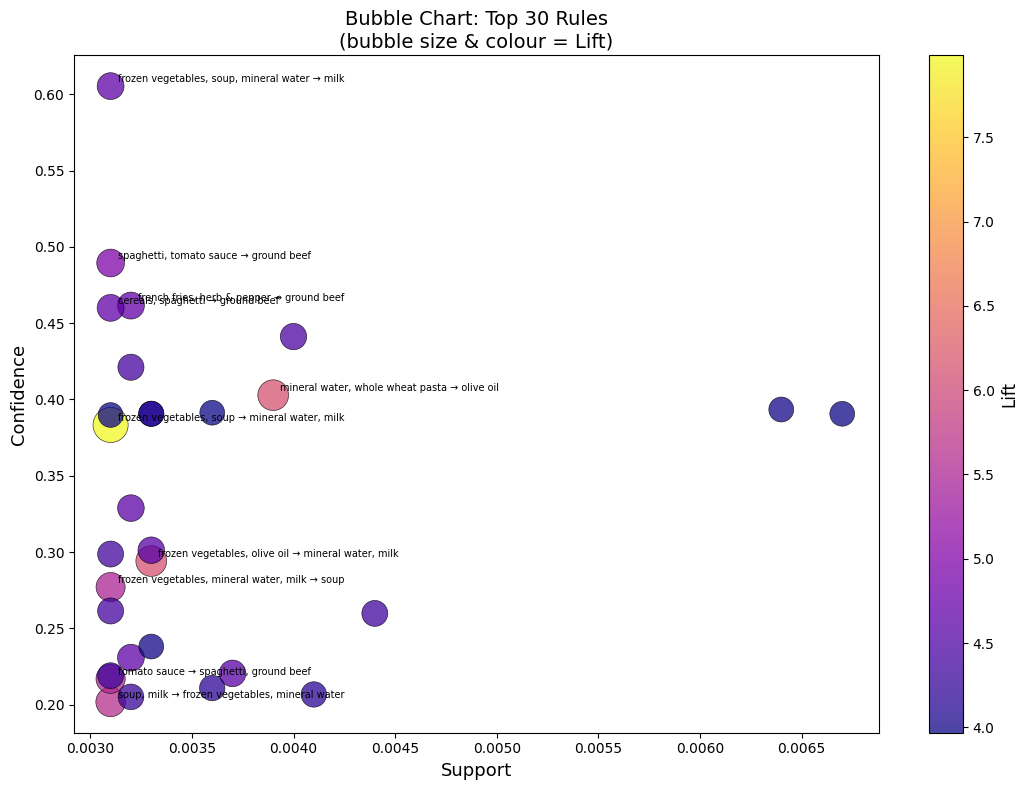

In [13]:
top30 = rules_df.head(30).copy()
top30['Rule'] = top30['Antecedent'] + ' → ' + top30['Consequent']

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    top30['Support'],
    top30['Confidence'],
    s=top30['Lift'] * 80,   # bubble size proportional to lift
    c=top30['Lift'],
    cmap='plasma',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift', fontsize=12)
ax.set_xlabel('Support', fontsize=13)
ax.set_ylabel('Confidence', fontsize=13)
ax.set_title('Bubble Chart: Top 30 Rules\n(bubble size & colour = Lift)', fontsize=14)

# Annotate top 10 bubbles
for _, row in top30.head(10).iterrows():
    ax.annotate(row['Rule'],
                xy=(row['Support'], row['Confidence']),
                fontsize=7,
                xytext=(5, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [14]:
strong_rules = rules_df[
    (rules_df['Lift'] > 2) &
    (rules_df['Confidence'] > 0.3) &
    (rules_df['Support'] > 0.005)
].reset_index(drop=True)

print(f"Strong rules (Lift>2, Confidence>0.3, Support>0.005): {len(strong_rules)}")
strong_rules

Strong rules (Lift>2, Confidence>0.3, Support>0.005): 83


,Antecedent,Consequent,Antecedent Length,Consequent Length,Rule Length,Support,Confidence,Lift
0,"spaghetti, herb & pepper",ground beef,2,1,3,0.0064,0.3934,4.0044
1,"herb & pepper, mineral water",ground beef,2,1,3,0.0067,0.3906,3.9757
2,"spaghetti, tomatoes",frozen vegetables,2,1,3,0.0067,0.3185,3.3411
3,"spaghetti, grated cheese",ground beef,2,1,3,0.0053,0.3226,3.2831
4,"shrimp, mineral water",frozen vegetables,2,1,3,0.0072,0.3051,3.2006
...,...,...,...,...,...,...,...,...
78,"herb & pepper, mineral water",spaghetti,2,1,3,0.0060,0.3516,2.0192
79,"cake, milk",mineral water,2,1,3,0.0064,0.4800,2.0137
80,"frozen vegetables, milk",spaghetti,2,1,3,0.0083,0.3503,2.0118
81,"spaghetti, cooking oil",mineral water,2,1,3,0.0076,0.4790,2.0095
